<a href="https://colab.research.google.com/github/miryam-bit/foodDeliveryFlutter/blob/main/clustering_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Notebook 3 — Clustering: Spatial Taxi Hotspot Discovery

**ML Paradigm:** Unsupervised Learning (Clustering)  
**Features:** `pickup_latitude`, `pickup_longitude` ONLY  
**Goal:** Discover geographic zones of taxi activity without any labels.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/ML

/content/drive/MyDrive/ML


## 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster  import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics  import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded ✔')

Libraries loaded ✔


In [ ]:
FILE_PATH = 'yellow_tripdata_2015-01.csv'

df_raw = pd.read_csv(
    FILE_PATH,
    parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'],
    nrows=1_000_000
)

print(f'Shape: {df_raw.shape}')

Shape: (1000000, 19)


## 2. Exploratory Data Analysis (EDA)

In [ ]:
print('=== Missing Values (spatial columns) ===')
print(df_raw[['pickup_latitude', 'pickup_longitude']].isnull().sum())
print()
print('=== Latitude Range ===')
print(f"Min lat: {df_raw['pickup_latitude'].min():.4f}")
print(f"Max lat: {df_raw['pickup_latitude'].max():.4f}")
print()
print('=== Longitude Range ===')
print(f"Min lon: {df_raw['pickup_longitude'].min():.4f}")
print(f"Max lon: {df_raw['pickup_longitude'].max():.4f}")

=== Missing Values (spatial columns) ===
pickup_latitude     0
pickup_longitude    0
dtype: int64

=== Latitude Range ===
Min lat: 0.0000
Max lat: 49.3890

=== Longitude Range ===
Min lon: -87.4519
Max lon: 0.0000


In [ ]:
print(df_raw[['pickup_latitude','pickup_longitude']].describe())

       pickup_latitude  pickup_longitude
count   1000000.000000    1000000.000000
mean         39.975328        -72.566400
std           5.569001         10.109116
min           0.000000        -87.451874
25%          40.735687        -73.991684
50%          40.753239        -73.981583
75%          40.767700        -73.966606
max          49.389046          0.000000


In [ ]:
# ── Drop nulls ────────────────────────────────────────────────────────────────
df_raw.dropna(inplace=True)

# ── Filter to New York City bounding box ─────────────────────────────────────
# NYC: lat 40.4 – 40.9, lon -74.3 – -73.7
df_clean = df_raw[
    (df_raw['pickup_latitude'].between(40.5, 41.0)) &
    (df_raw['pickup_longitude'].between(-74.3, -73.6))
]

## 3. Preprocessing — Coordinate Filtering & Scaling

In [ ]:
print(df_clean.shape)

(980845, 19)


In [ ]:
print(df_clean[['pickup_latitude','pickup_longitude']].describe())

       pickup_latitude  pickup_longitude
count    980845.000000     980845.000000
mean         40.751181        -73.974685
std           0.027024          0.035554
min          40.544922        -74.296074
25%          40.737236        -73.991867
50%          40.754074        -73.981926
75%          40.768070        -73.967896
max          40.993294        -73.610893


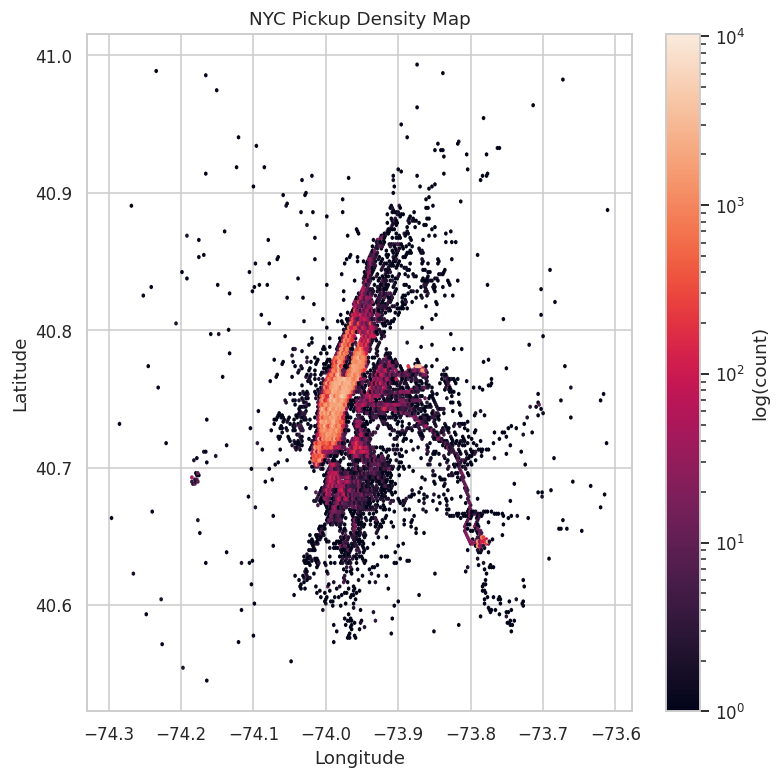

In [ ]:
plt.figure(figsize=(8,8))

plt.hexbin(
    df_clean['pickup_longitude'],
    df_clean['pickup_latitude'],
    gridsize=250,
    bins='log'
)

plt.title("NYC Pickup Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="log(count)")
plt.show()

In [ ]:
# ── Scale features (required for KMeans) ────────────────────"Scaling standardizes coordinates to improve clustering performance."
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(df_clean[['pickup_latitude', 'pickup_longitude']])

print('Scaling complete — mean ≈ 0, std ≈ 1')
print(f'Scaled array shape: {coords_scaled.shape}')

Scaling complete — mean ≈ 0, std ≈ 1
Scaled array shape: (980845, 2)


## 4. Elbow Method to Choose Optimal K

In [ ]:
# Use a representative subsample for the elbow search (faster)
ELBOW_SAMPLE = 1000_000
np.random.seed(42)
idx_sample = np.random.choice(len(coords_scaled), size=min(ELBOW_SAMPLE, len(coords_scaled)),
                               replace=False)
coords_elbow = coords_scaled[idx_sample]

K_RANGE  = range(2, 13)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5,
                max_iter=200, random_state=42)
    labels = km.fit_predict(coords_elbow)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(coords_elbow, labels, sample_size=20_000,
                                       random_state=42))
    print(f'k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

print('\nElbow search done.')

k= 2  inertia=1,134,211  silhouette=0.8118
k= 3  inertia=580,676  silhouette=0.4599
k= 4  inertia=409,479  silhouette=0.4197
k= 5  inertia=275,985  silhouette=0.4410
k= 6  inertia=222,251  silhouette=0.3960
k= 7  inertia=192,671  silhouette=0.3961
k= 8  inertia=167,171  silhouette=0.3985
k= 9  inertia=149,204  silhouette=0.3630
k=10  inertia=131,247  silhouette=0.3875
k=11  inertia=117,523  silhouette=0.3913
k=12  inertia=107,045  silhouette=0.3924

Elbow search done.


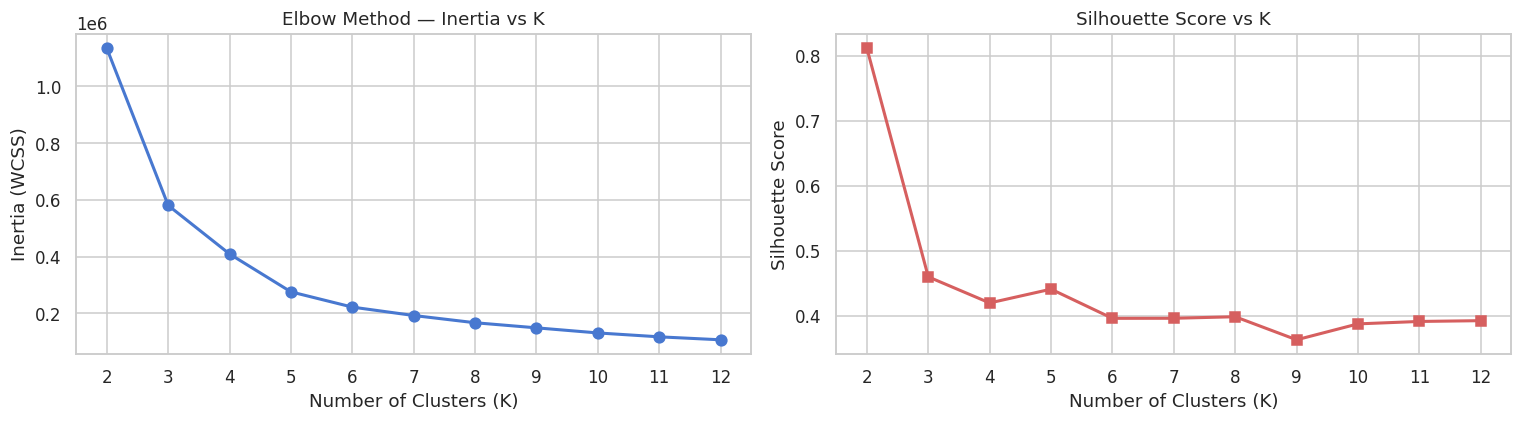

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow curve
axes[0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_RANGE))

# Silhouette scores
axes[1].plot(list(K_RANGE), sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('/content/nb3_elbow.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Choose K based on elbow + silhouette ─────────────────────────────────────
# Typical NYC taxi data shows a clear elbow around K=5–8.
# Adjust OPTIMAL_K below after reviewing the plots above.
OPTIMAL_K = 5
print(f'Selected OPTIMAL_K = {OPTIMAL_K}')
print(f'Silhouette at K={OPTIMAL_K}: {sil_scores[OPTIMAL_K - 2]:.4f}')

Selected OPTIMAL_K = 5
Silhouette at K=5: 0.4410


## 5. K-Means Clustering (Full Dataset)

In [ ]:
km_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

df_clean['cluster_id'] = km_final.fit_predict(coords_scaled)

print(f'K-Means fit complete (K={OPTIMAL_K}).')
print('Cluster sizes:')
print(df_clean['cluster_id'].value_counts().sort_index())

K-Means fit complete (K=5).
Cluster sizes:
cluster_id
0    278815
1    231485
2     18643
3     25893
4    426009
Name: count, dtype: int64


## 6. Evaluation

In [ ]:
final_sil = silhouette_score(
    coords_scaled, df_clean['cluster_id'],
    sample_size=50_000, random_state=42
)
print(f'Final Model Inertia   : {km_final.inertia_:,.2f}')
print(f'Final Silhouette Score: {final_sil:.4f}')
print()
print('Cluster centroids (original coordinate space):')
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig,
                            columns=['centroid_lat', 'centroid_lon'])
centroid_df.index.name = 'cluster_id'
print(centroid_df.round(5))
#We performed inverse transformation to map each cluster back to its real geographic location.

Final Model Inertia   : 275,972.12
Final Silhouette Score: 0.4449

Cluster centroids (original coordinate space):
            centroid_lat  centroid_lon
cluster_id                            
0               40.72593     -73.99530
1               40.78065     -73.96219
2               40.64681     -73.78504
3               40.76787     -73.87652
4               40.75524     -73.98225


## 7. Visualization — Cluster Map

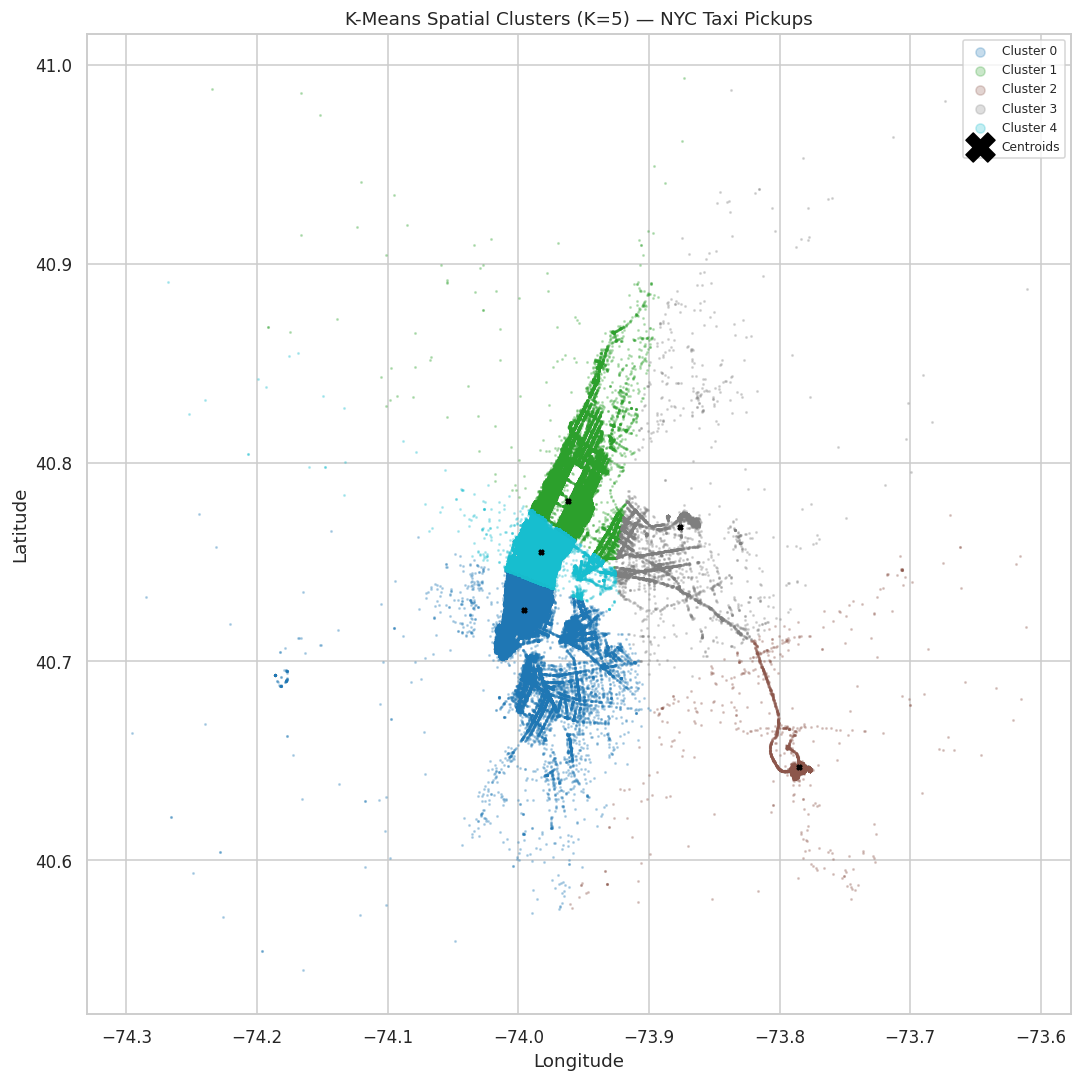

In [ ]:
# Sample for plotting performance
PLOT_SAMPLE = 1000_000
df_plot = df_clean.sample(min(PLOT_SAMPLE, len(df_clean)), random_state=42)

palette = plt.cm.get_cmap('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(10, 10))

for cid in range(OPTIMAL_K):
    mask = df_plot['cluster_id'] == cid
    ax.scatter(
        df_plot.loc[mask, 'pickup_longitude'],
        df_plot.loc[mask, 'pickup_latitude'],
        s=1, alpha=0.25, color=palette(cid), label=f'Cluster {cid}'
    )

# Plot centroids
ax.scatter(
    centroids_orig[:, 1], centroids_orig[:, 0],
    s=10, marker='X', color='black', zorder=5, label='Centroids'
)

ax.set_title(f'K-Means Spatial Clusters (K={OPTIMAL_K}) — NYC Taxi Pickups')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(markerscale=6, fontsize=8)
plt.tight_layout()
plt.savefig('/content/nb3_cluster_map.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. Post-Hoc Interpretation — Zone Activity Levels

> ⚠️ The interpretation below is performed **after** clustering is complete. Activity level (high / medium / low) is derived solely from **cluster size** (trip count) — it was NOT used during model training.

In [ ]:
# Count trips per cluster → proxy for activity level
cluster_stats = (
    df_clean.groupby('cluster_id')
      .size()
      .reset_index(name='trip_count')
      .merge(centroid_df.reset_index(), on='cluster_id')
      .sort_values('trip_count', ascending=False)
)

# Assign activity tier using tertile split
q33 = cluster_stats['trip_count'].quantile(0.33)
q66 = cluster_stats['trip_count'].quantile(0.66)

def activity_tier(count):
    if count >= q66:  return 'HIGH Activity'
    elif count >= q33: return 'MEDIUM Activity'
    else:              return 'LOW Activity'

cluster_stats['activity_level'] = cluster_stats['trip_count'].apply(activity_tier)

print('=== Post-Hoc Cluster Activity Summary ===')
cluster_stats[['cluster_id', 'trip_count', 'centroid_lat',
               'centroid_lon', 'activity_level']].to_string(index=False)
print(cluster_stats[['cluster_id', 'trip_count', 'centroid_lat',
                       'centroid_lon', 'activity_level']].to_string(index=False))
# we analyze how active each cluster is by counting trips and assigning activity levels accordingly.

=== Post-Hoc Cluster Activity Summary ===
 cluster_id  trip_count  centroid_lat  centroid_lon  activity_level
          4      426009     40.755235    -73.982249   HIGH Activity
          0      278815     40.725933    -73.995299   HIGH Activity
          1      231485     40.780654    -73.962193 MEDIUM Activity
          3       25893     40.767874    -73.876524    LOW Activity
          2       18643     40.646807    -73.785041    LOW Activity


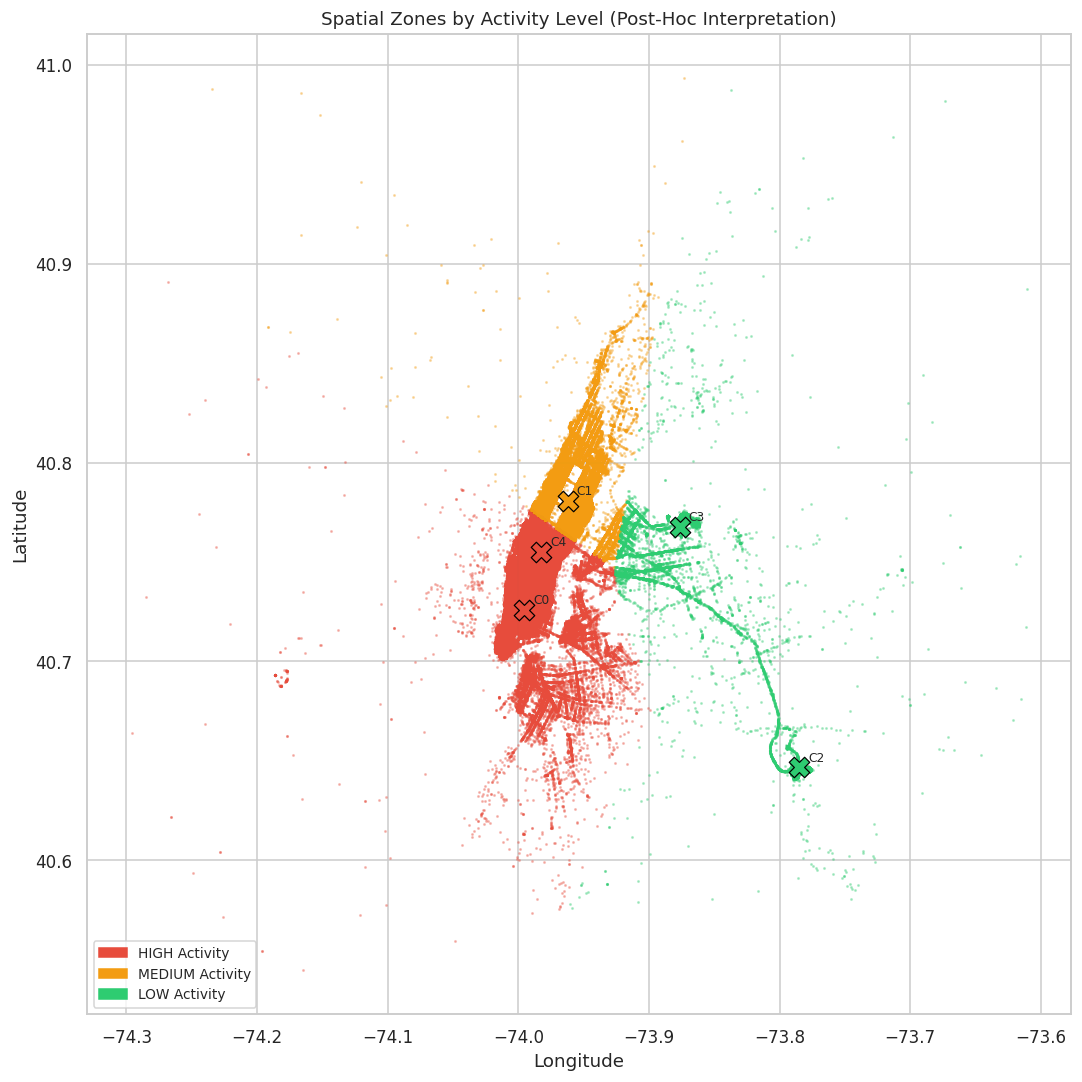

In [ ]:
# Map clusters with activity tier colour
tier_colors = {'HIGH Activity': '#e74c3c', 'MEDIUM Activity': '#f39c12', 'LOW Activity': '#2ecc71'}
tier_map    = cluster_stats.set_index('cluster_id')['activity_level'].to_dict()

df_plot['activity_level'] = df_plot['cluster_id'].map(tier_map)

fig, ax = plt.subplots(figsize=(10, 10))

for tier, color in tier_colors.items():
    mask = df_plot['activity_level'] == tier
    ax.scatter(
        df_plot.loc[mask, 'pickup_longitude'],
        df_plot.loc[mask, 'pickup_latitude'],
        s=1, alpha=0.3, color=color, label=tier
    )

# Centroids
for _, row in cluster_stats.iterrows():
    ax.scatter(row['centroid_lon'], row['centroid_lat'],
               s=180, marker='X',
               color=tier_colors[row['activity_level']],
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(f"C{int(row['cluster_id'])}",
                (row['centroid_lon'], row['centroid_lat']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

patches = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=patches, markerscale=6, fontsize=9)

ax.set_title('Spatial Zones by Activity Level (Post-Hoc Interpretation)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('/content/nb3_activity_map.png', bbox_inches='tight', dpi=130)
plt.show()
# visualize the discovered clusters on the city map, colouring each zone by its activity level and marking the cluster centroids to clearly show the spatial distribution of taxi demand.